In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))  
sys.path.append(project_root)

In [2]:
from feature_engineering import FeatureExtraction


In [3]:
file_path = "../../data/Expenditure-of-local-bodies.xlsx"
if not file_path:
    print("File not exist!")
else:
    print("Good to go☺️")

Good to go☺️


In [4]:
feature_extraction = FeatureExtraction(fname=file_path, province_name="Karnali Province")
budget_df, expense_df = feature_extraction.fit()
budget_df.head()

Original data extracted successfully☺️
DataFrame Renamed successfully☺️
ALL THE OPERSTIONS WERE SUCCESSFUL😊


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
596,587,Aathbiskot Municipality,59.695438,48.4714,0.0,108.166838,1.277715
597,588,Chaurjahari Municipality,33.453178,38.592686,0.0,72.045864,1.259169
598,589,Musikot Municipality,45.940986,33.755221,0.0,79.696207,15.420442
599,590,Triveni Rural Municipality,35.633631,18.38758,0.0,54.021211,1.258718
600,591,Baafikot Rural Municipality,31.681857,13.1843,0.03,44.896158,7.663248


In [5]:
from visualization import CompositionAnalysis

/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/composition.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe["Total"] = self.dataframe["Total"].fillna(0)


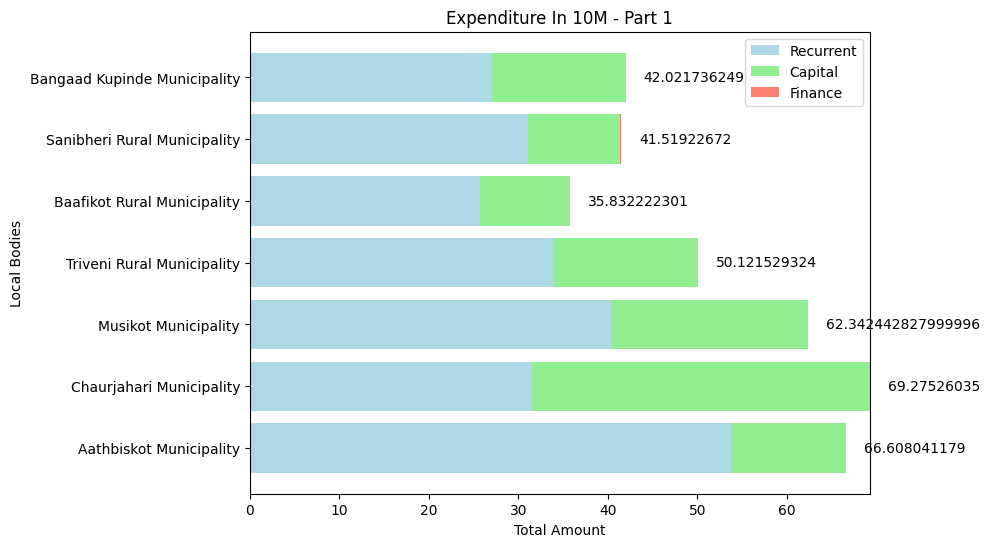

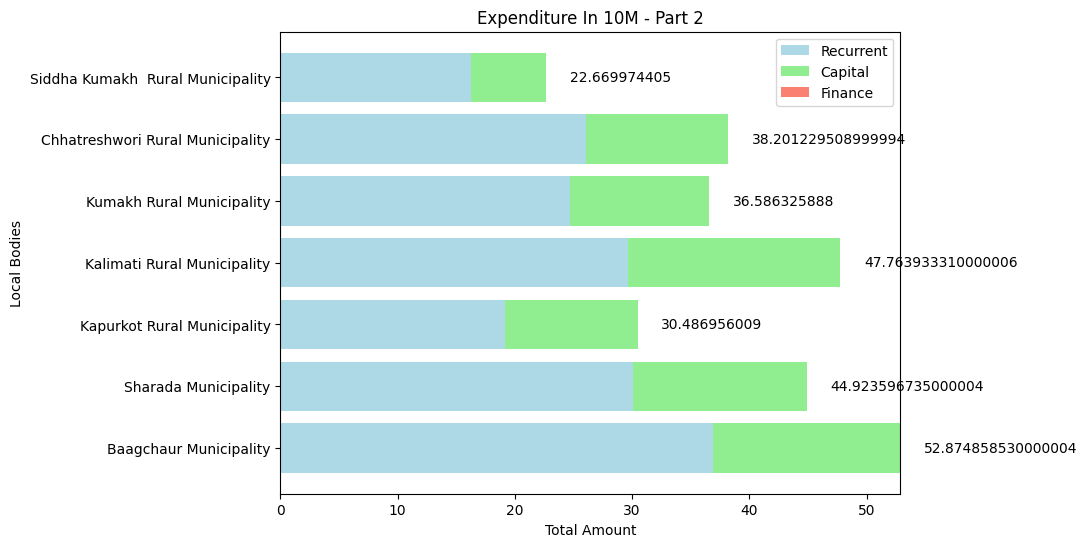

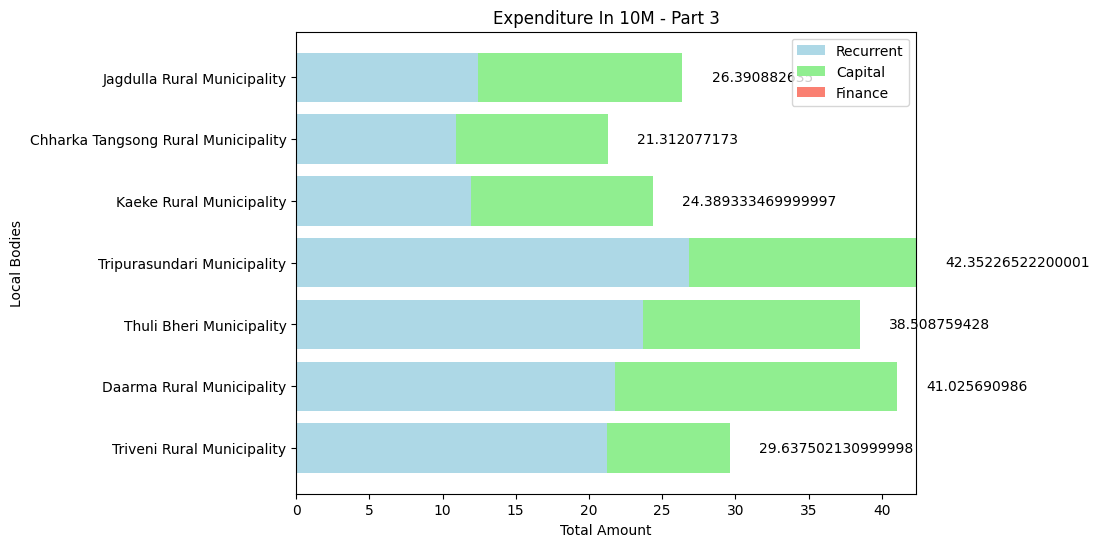

In [6]:
composition_analysis = CompositionAnalysis(dataframe=expense_df, title="Expenditure")
composition_analysis.plot_composition_bar()

In [7]:
expense_df["Utilization_rate"] = (expense_df["Total"]/budget_df["Total"])*100
expense_df.head()

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance,Utilization_rate
596,587,Aathbiskot Municipality,53.719575,12.888467,0.0,66.608041,1.277715,61.578985
597,588,Chaurjahari Municipality,31.551898,37.723363,0.0,69.275260,1.259169,96.154389
598,589,Musikot Municipality,40.351674,21.990769,0.0,62.342443,15.420442,78.225107
599,590,Triveni Rural Municipality,33.978703,16.142827,0.0,50.121529,1.258718,92.781203
600,591,Baafikot Rural Municipality,25.690501,10.141722,0.0,35.832222,7.663248,79.811334


In [8]:
df_shorted = expense_df.sort_values(by='Utilization_rate', ascending=False)
df_shorted.head()

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance,Utilization_rate
597,588,Chaurjahari Municipality,31.551898,37.723363,0.0,69.275260,1.259169,96.154389
662,653,Naumule Rural Municipality,30.791301,17.757531,0.0,48.548832,1.870113,95.044078
599,590,Triveni Rural Municipality,33.978703,16.142827,0.0,50.121529,1.258718,92.781203
631,622,Soru Rural Municipality,20.556355,25.410483,0.0,45.966838,14.27496,92.351563
637,628,Sarkegad Rural Municipality,23.556617,14.784773,0.0,38.341389,0.298309,92.211595


In [9]:
total_att_limit = 28
df_slice = df_shorted.head(total_att_limit).copy()
df_slice.tail()

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance,Utilization_rate
658,649,Narayan Municipality,33.182752,18.824122,0.0,52.006874,6.247856,85.575299
622,613,Guthichaur Rural Municipality,16.8527,12.827897,0.0,29.680597,2.702645,85.102232
674,665,Simta Rural Municipality,30.60032,16.353581,0.0,46.953901,3.178089,85.03973
613,604,Tripurasundari Municipality,26.847028,15.505237,0.0,42.352265,2.607515,84.997761
663,654,Bhagwatimai Rural Municipality,26.239345,21.719361,0.0,47.958706,5.128246,84.297799


In [10]:
df_slice.shape

(28, 8)

In [11]:
chunks = [df_slice.iloc[i: i + 7] for i in range(0, len(df_slice), 7)]
len(df_slice)

28

In [12]:
len(chunks)

4

In [13]:
chunks

[      SN                   Local Body  Recurrent    Capital Financial  \
 597  588     Chaurjahari Municipality  31.551898  37.723363       0.0   
 662  653   Naumule Rural Municipality  30.791301  17.757531       0.0   
 599  590   Triveni Rural Municipality  33.978703  16.142827       0.0   
 631  622      Soru Rural Municipality  20.556355  25.410483       0.0   
 637  628  Sarkegad Rural Municipality  23.556617  14.784773       0.0   
 638  629    Simkot Rural Municipality  22.975827  19.664242       0.0   
 616  607  Jagdulla Rural Municipality  12.407706  13.983177       0.0   
 
          Total Cash Balance Utilization_rate  
 597  69.275260     1.259169        96.154389  
 662  48.548832     1.870113        95.044078  
 599  50.121529     1.258718        92.781203  
 631  45.966838     14.27496        92.351563  
 637  38.341389     0.298309        92.211595  
 638  42.640069      0.66136        91.102752  
 616  26.390883     0.813376        90.582438  ,
       SN            

In [14]:
import matplotlib.pyplot as plt

/tmp/ipykernel_127724/2361233210.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


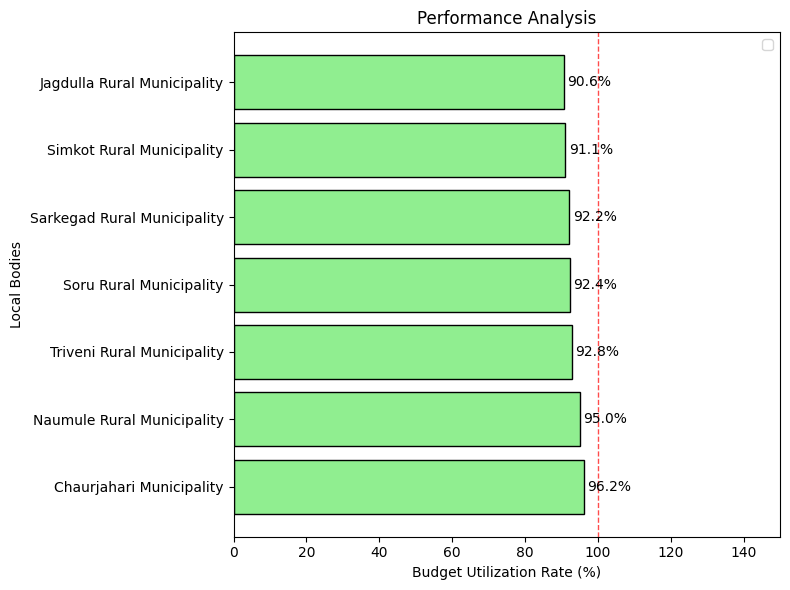

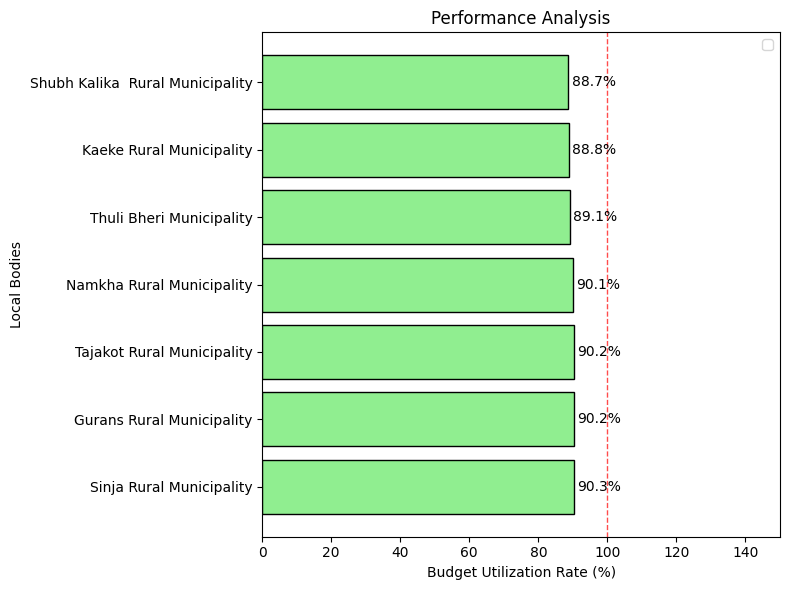

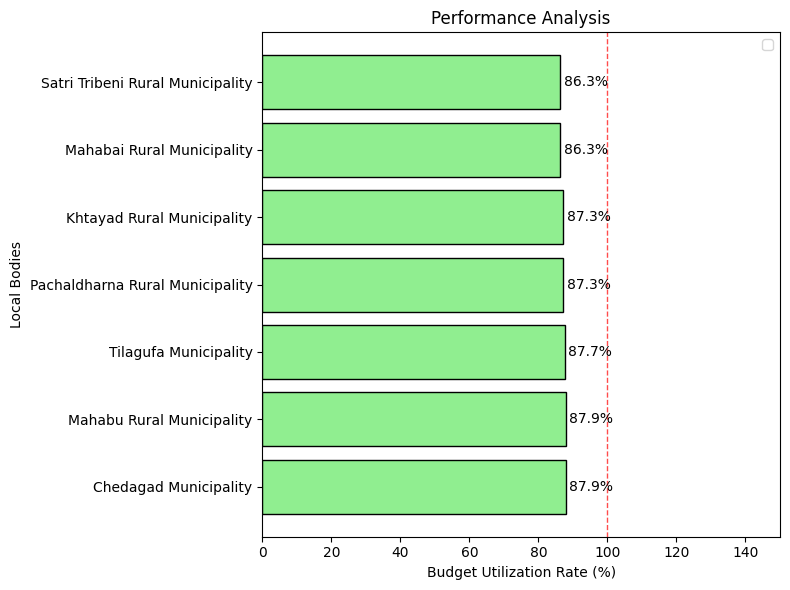

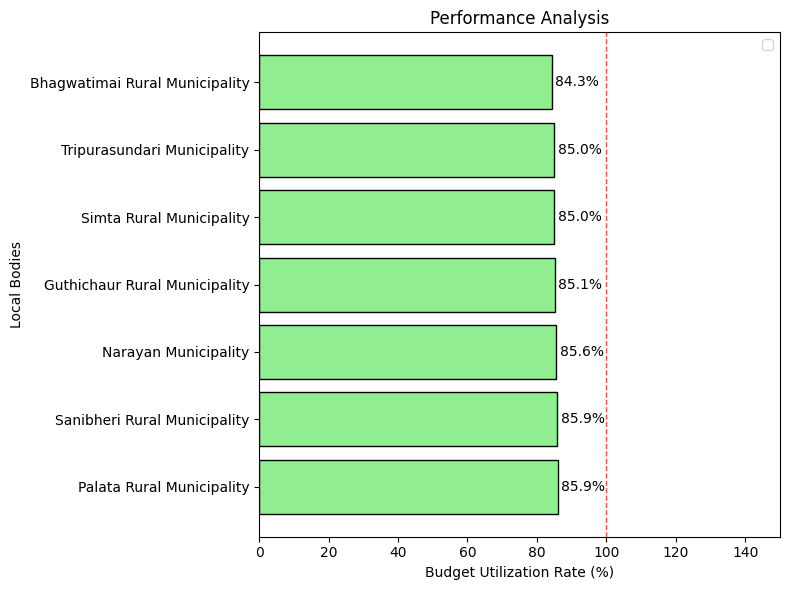

In [15]:
for idx, chunk in enumerate(chunks):
    local_bodies = chunk["Local Body"]
    utilization_rates = chunk["Utilization_rate"]

    fig, ax = plt.subplots(figsize=(8,6))

    colors = ['lightgreen' if rate <= 100 and rate >= 75 
                      else '#ffc107' if rate < 75 and rate >= 50 
                      else '#dc3545' 
                      for rate in utilization_rates]
    bars = ax.barh(local_bodies,
                   utilization_rates,
                   color=colors,
                   edgecolor='black')
    
    for bar, rate in zip(bars, utilization_rates):
        ax.text(bar.get_width() + 1,
                bar.get_y() + bar.get_height()/2,
                f'{rate:.1f}%', 
                va='center', 
                ha='left', 
                fontsize=10)
    ax.set_xlim(0,150)
    ax.set_xlabel("Budget Utilization Rate (%)")
    ax.set_ylabel("Local Bodies")
    ax.set_title("Performance Analysis")

    ax.axvline(100, color='red', linestyle='--', linewidth=1, alpha=0.7)

    plt.tight_layout()
    plt.legend()
    plt.show()

In [16]:
# Lets try implemented one 
project_root = os.path.abspath(os.path.join(os.getcwd(), '..',))  
sys.path.append(project_root)

from performance import PerformanceAnalysis

In [17]:
feature_extraction = FeatureExtraction(fname=file_path, province_name="Bagmati Province")
expense_df_bag, budget_df_bag = feature_extraction.fit()
expense_df_bag.head()

Original data extracted successfully☺️
DataFrame Renamed successfully☺️
ALL THE OPERSTIONS WERE SUCCESSFUL😊


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
277,274,Jiri Municipality,32.1781,21.796821,0.0,53.974921,5.259159
278,275,Bhimeshwor Municipality,40.456662,53.925065,0.15,94.531727,6.743792
279,276,Kalinchwok Rural Municipality,43.495598,30.00791,0.0,73.503508,8.158327
280,277,Gaurisahnkar Rural Municipality,29.82713,20.8173,0.0,50.64443,4.510428
281,278,Tamakoshi Rural Municipality,44.341532,26.595364,0.0,70.936896,17.064383


/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0)
/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


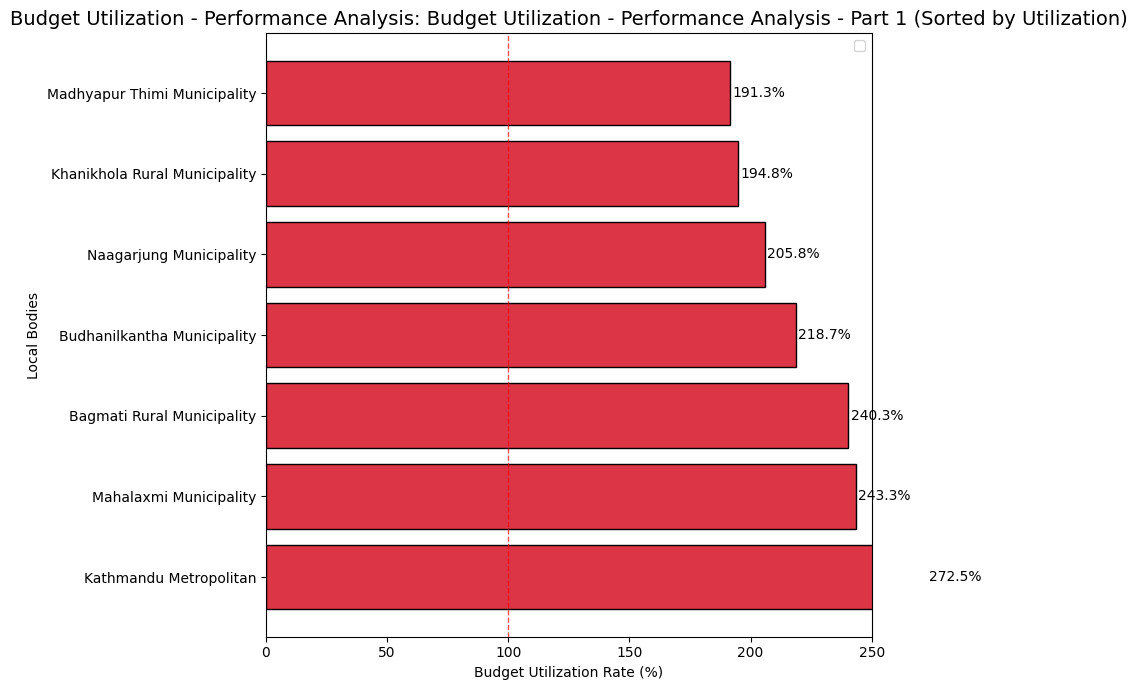

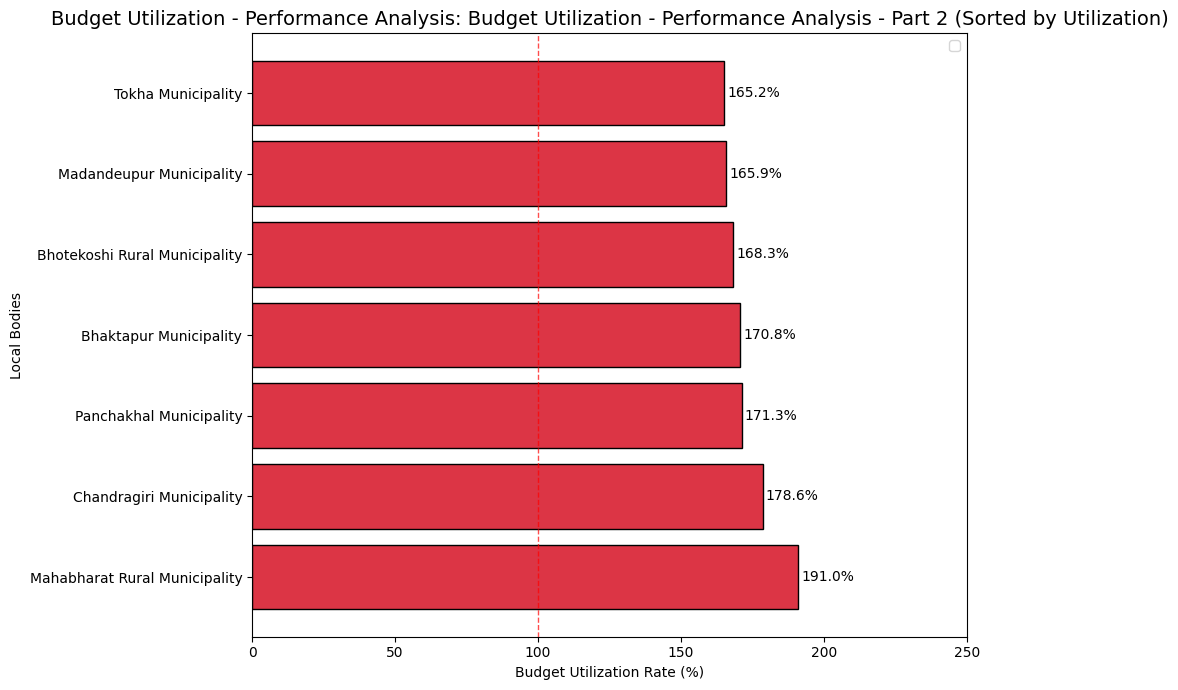

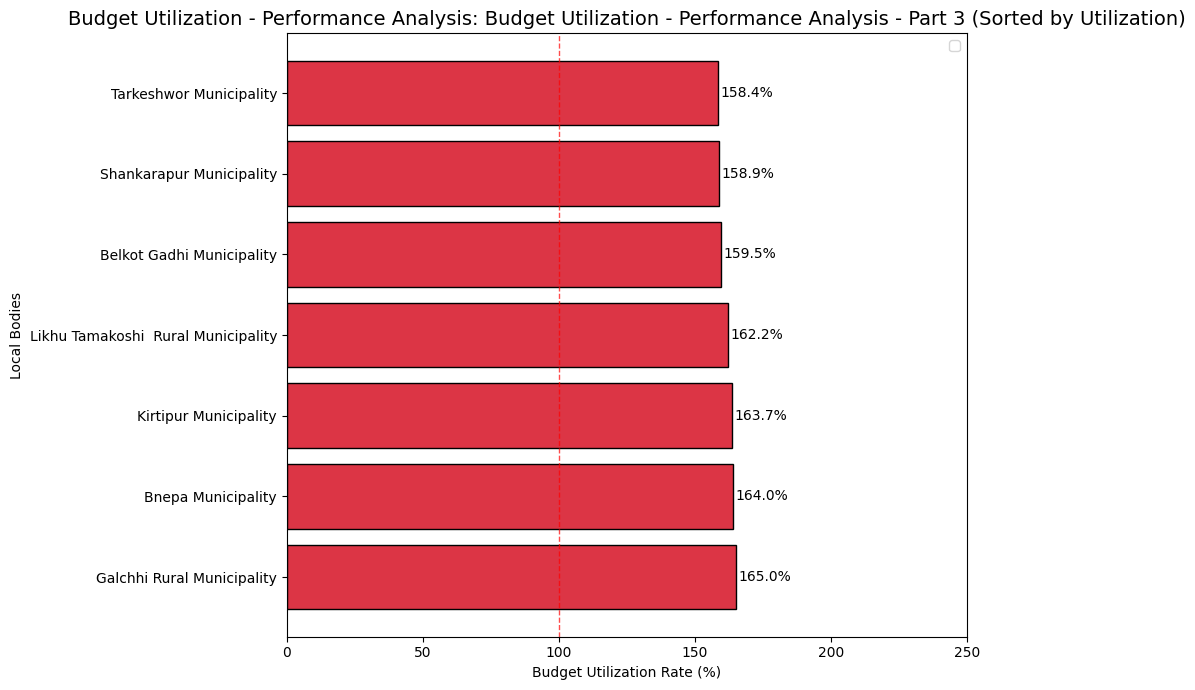

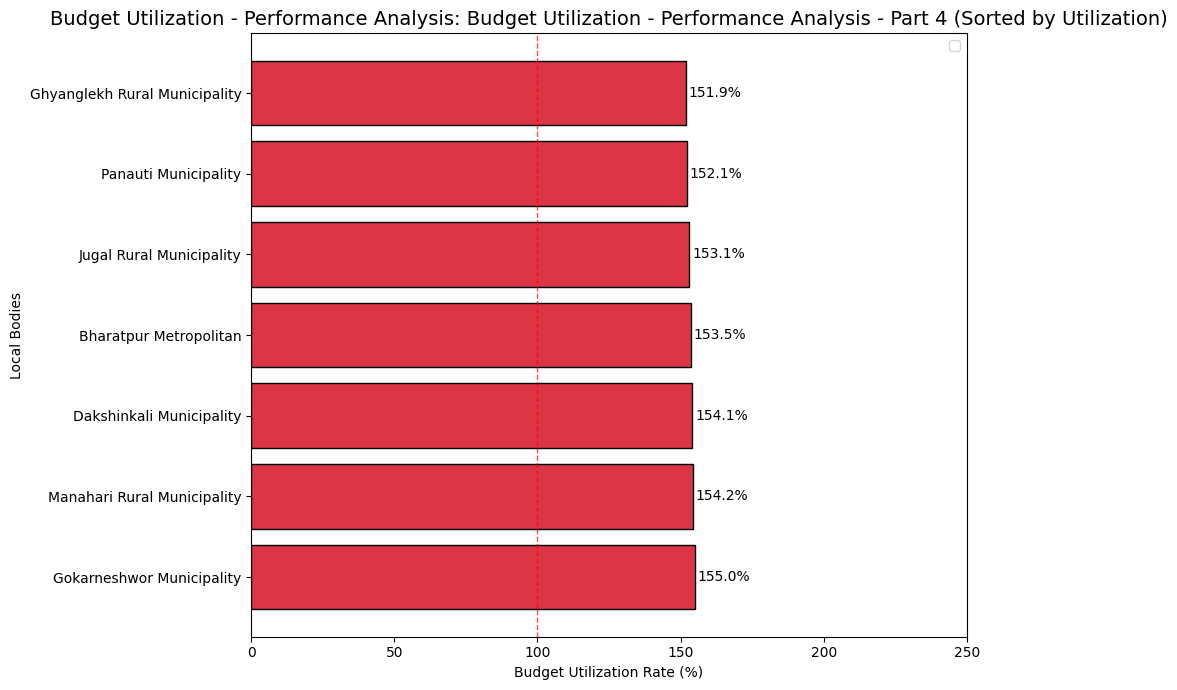

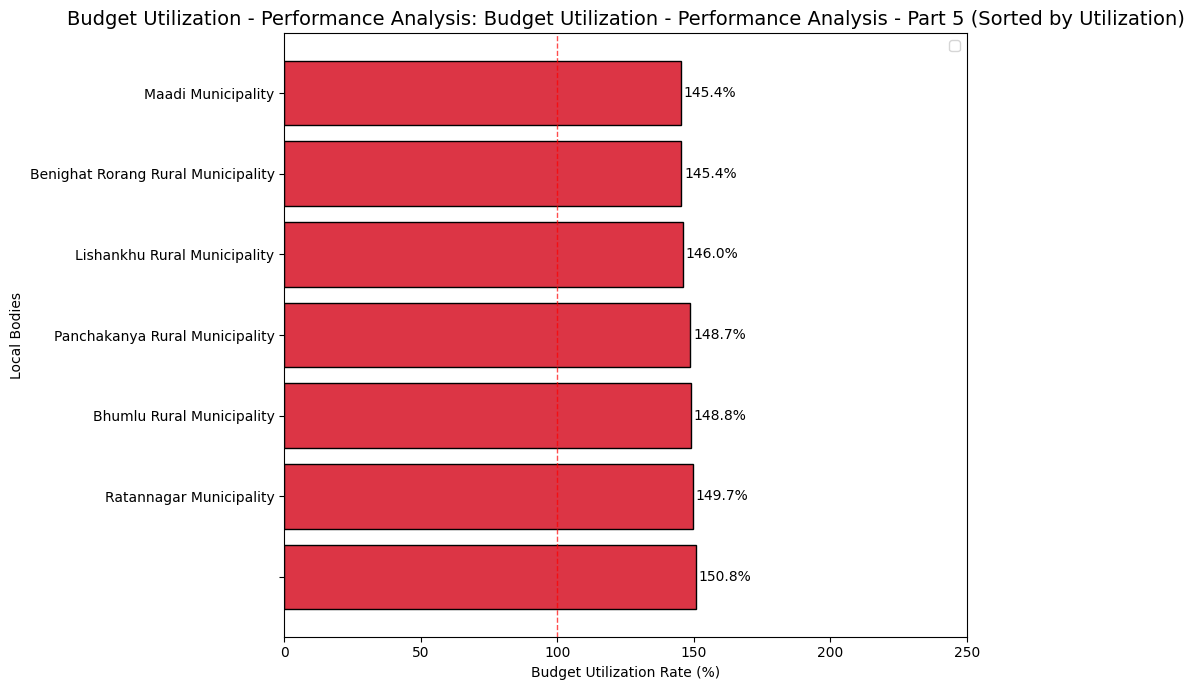

In [18]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df_bag,
                                           dataframe_expense=expense_df_bag,
                                           total_attributes_limit=35)
performance_analysis.plot_utilization_bar()

/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0)
/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


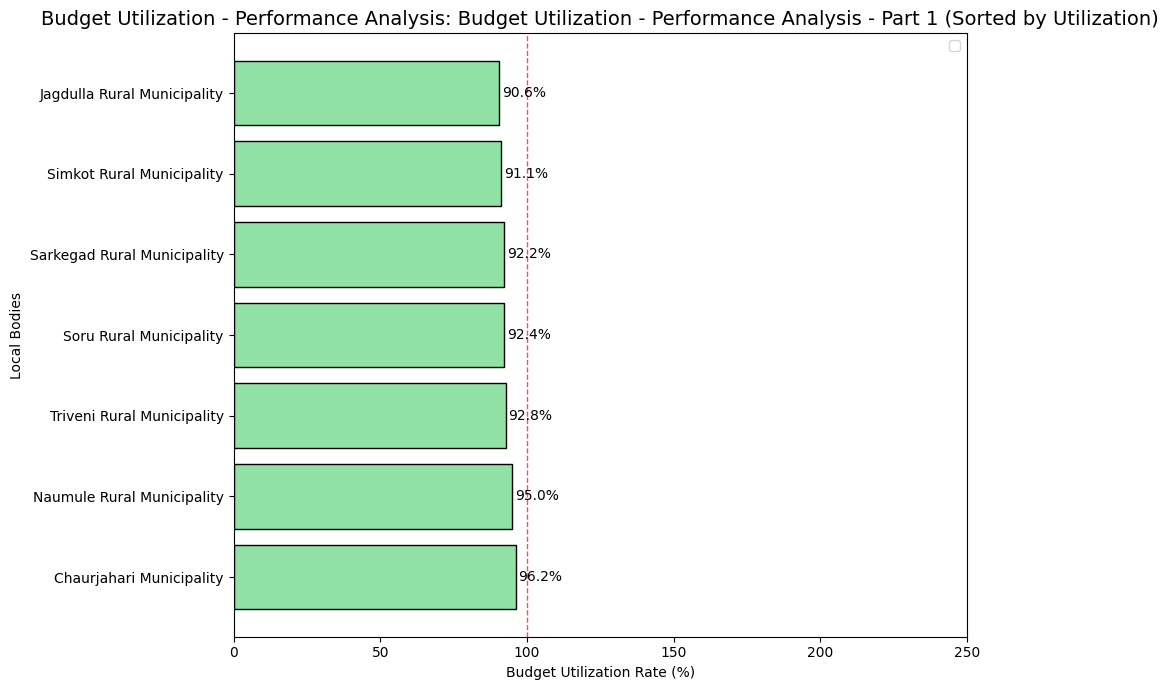

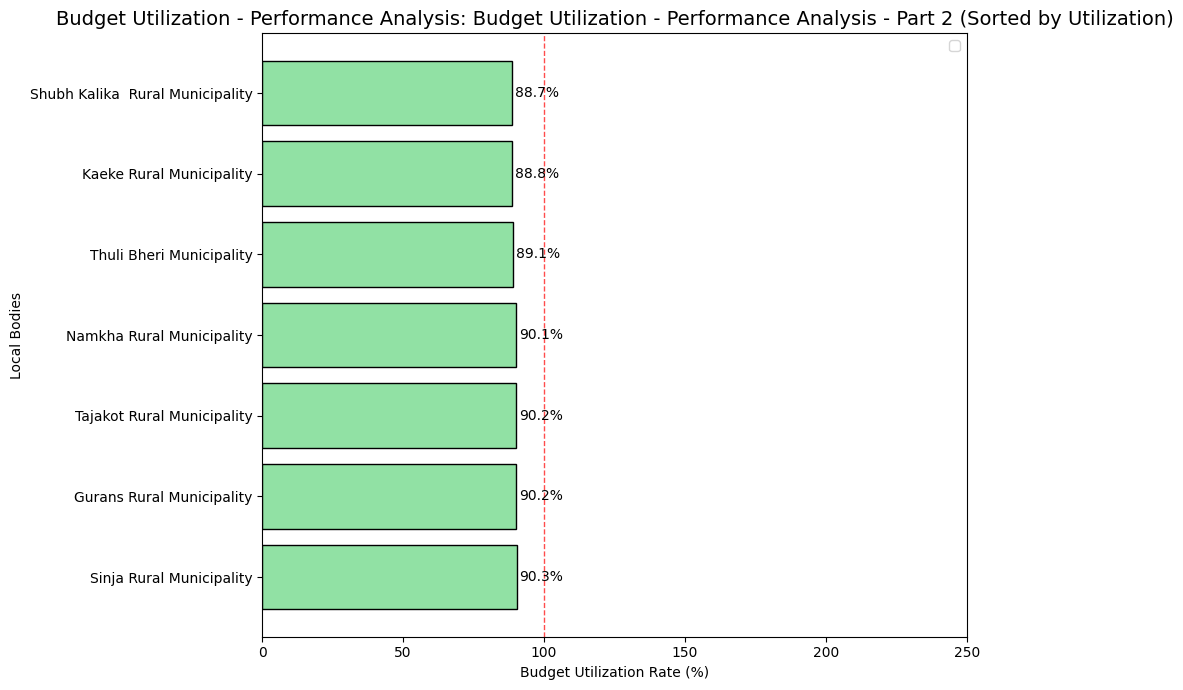

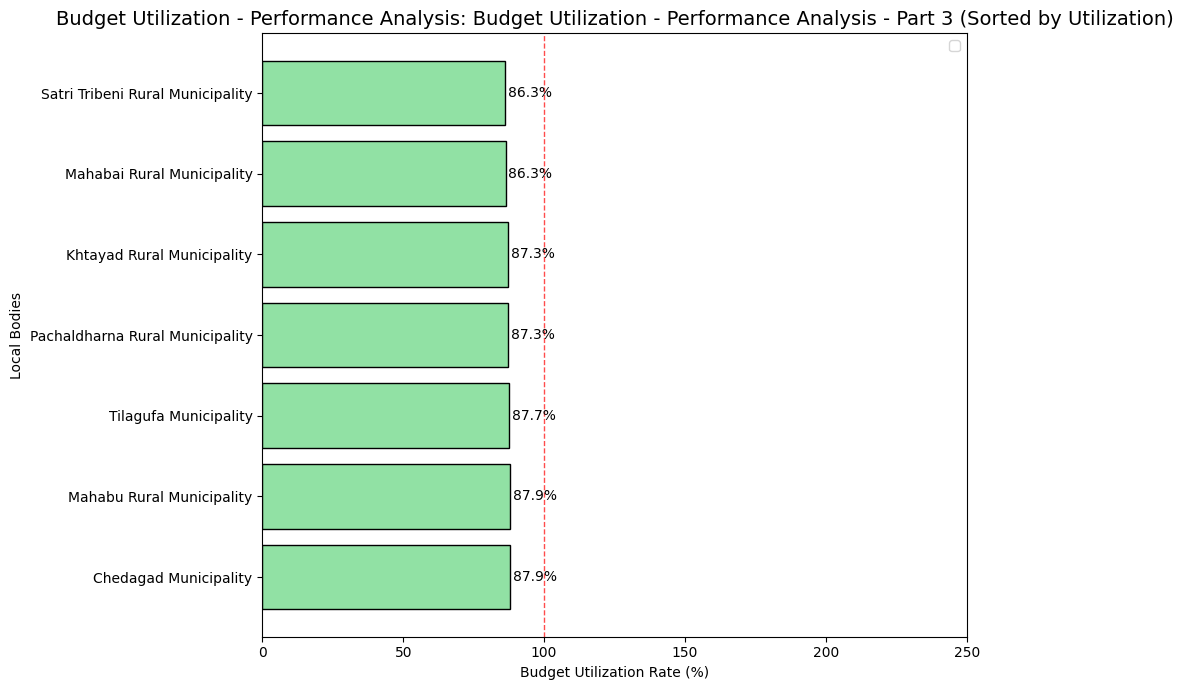

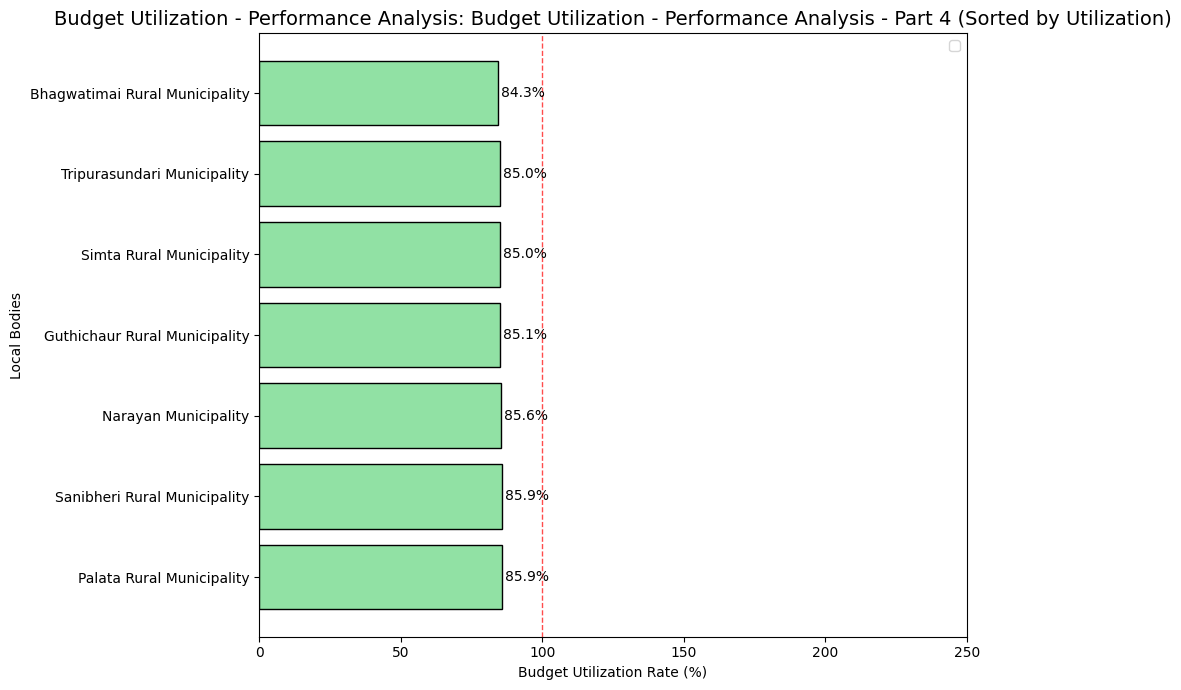

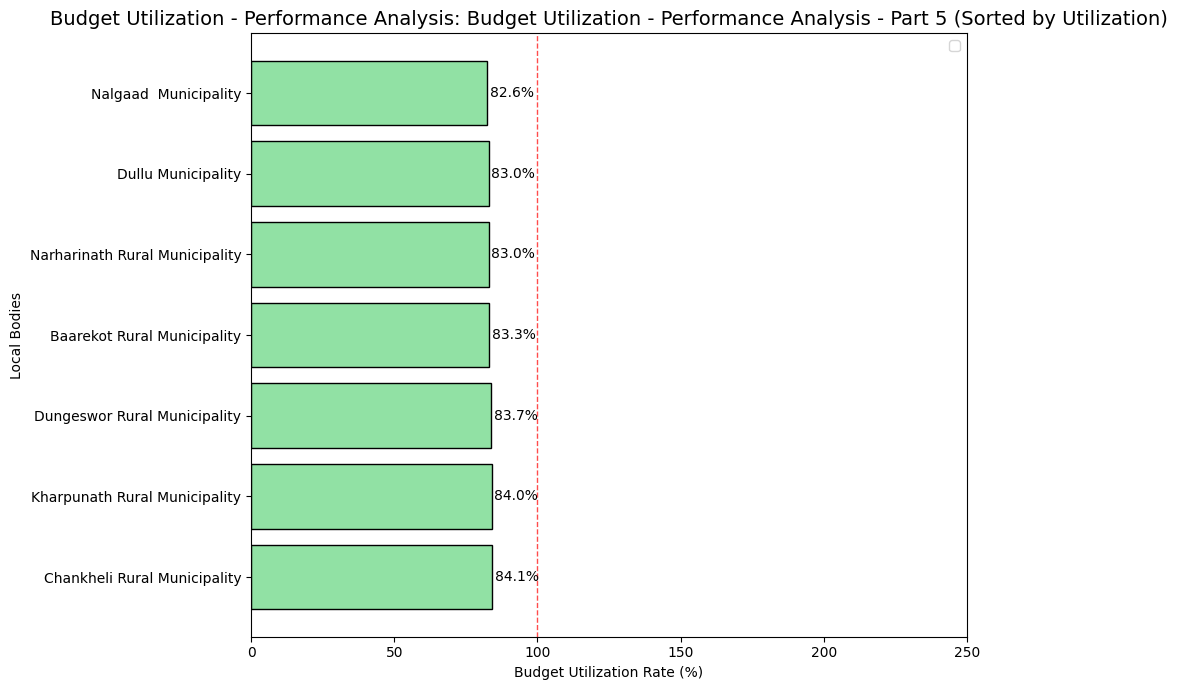

In [19]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df,
                                           dataframe_expense=expense_df,
                                           total_attributes_limit=35)
performance_analysis.plot_utilization_bar()